# Multi-label ViT notebook

In this notebook we implement a vision transformer (Dinov3), pretrained on satellite imagery. We finetune it on the multi-label training dataset, and then test the performance on the validation dataset.

## Imports

In [16]:
%load_ext autoreload
%autoreload 2
# Internal import
import deep_learning_land_use_classification.config as config
import deep_learning_land_use_classification.evaluation as evaluation
from deep_learning_land_use_classification.dataset import get_multi_label_data
import deep_learning_land_use_classification.wanddb_helpers as wh
from deep_learning_land_use_classification.early_stopping import EarlyStopper

# External imports
import torch
from transformers import AutoImageProcessor, AutoModel
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import numpy as np
import torch.nn as nn
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import re


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Getting data
The data is split into training (64%), validation (16%) and test (20%). Training is used for model training, validation is used to tune hyperparameters and pick the best model, and testing is used to assess the performance of the final model. Data is split using multi-label stratified sampling from the iterative-stratification library.

## Getting data
The data is split into training (64%), validation (16%) and test (20%). Training is used for model training, validation is used to tune hyperparameters and pick the best model, and testing is used to assess the performance of the final model. Data is split using stratified sampling.

In [17]:
train_df, test_df, val_df,class_names, num_classes = get_multi_label_data()

In [18]:
# Wandb initialization for experiment tracking
run = wh.init_run(
    run_name="ViT unfrozen 02",
    task="multi",
    architecture="dinov3-vitl16",
    num_classes=num_classes,
    loss="BCEWithLogitsLoss",
    epochs=1,
    batch_size=32,
    learning_rate=1e-3,
    optimizer="AdamW",
    pretrained=True,
    pretraining_dataset="sat493m",
    pretraining_source="huggingface",
    weights="facebook/dinov3-vitl16-pretrain-sat493m",
    model_name=None,
    augmentation=False,
    early_stopping=True,
    patience=6,
    min_delta=0.001,
    backbone_frozen=False,
    backbone_learning_rate=1e-4,
    dropout=None,
)

class/airplane/f1,▁█
class/airplane/precision,▁█
class/airplane/recall,▁▁
class/bare_soil/f1,█▁
class/bare_soil/precision,▁█
class/bare_soil/recall,█▁
class/buildings/f1,▁█
class/buildings/precision,▁█
class/buildings/recall,█▁
class/cars/f1,▁█
+47,...


# Define model

In [19]:
# Define model and processor
pretrained_model_name = "facebook/dinov3-vitl16-pretrain-sat493m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)

In [20]:
print(processor)

DINOv3ViTImageProcessor {
  "data_format": "channels_first",
  "default_to_square": true,
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.43,
    0.411,
    0.296
  ],
  "image_processor_type": "DINOv3ViTImageProcessor",
  "image_std": [
    0.213,
    0.156,
    0.143
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}



In [21]:
# Define data augmentation for training
train_augs = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.02),
    transforms.RandomRotation(degrees=90)
])

In [22]:
class MultiLabelDataset(Dataset):
    def __init__(self, dataframe, class_names, transform=None, augment=None):
        self.df = dataframe.reset_index(drop=True)
        self.class_names = class_names
        self.transform = transform
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["path"]).convert("RGB")
        
        if self.augment and run.config.augmentation: # Apply augmentations only during training
                image = self.augment(image)
                
        inputs = processor(images=image, return_tensors="pt") # converts image to tensor and normalizes it
        inputs = {k: v.squeeze(0) for k, v in inputs.items()} # remove batch dimension

        label = torch.tensor(row[self.class_names].values.astype(np.float32))
            
        return inputs, label

In [23]:
# Create datasets and dataloaders
train_dataset = MultiLabelDataset(train_df, class_names, processor, augment=train_augs)
val_dataset  = MultiLabelDataset(val_df, class_names, processor, augment=None)

train_loader = DataLoader(train_dataset, batch_size=run.config.batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=run.config.batch_size, shuffle=False)

In [24]:
# this is a simple wrapper around the DINO backbone to add a classification head on top
class DinoClassifier(torch.nn.Module):
    def __init__(self, backbone, num_classes, dropout=0.0):
        super().__init__()
        self.backbone = backbone
        self.dropout = torch.nn.Dropout(p=dropout)
        self.classifier = torch.nn.Linear(
            backbone.config.hidden_size,
            num_classes
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values) # get the output of the backbone
        features = outputs.pooler_output
        features = self.dropout(features) if self.dropout.p > 0 else features
        return self.classifier(features)

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print ("Using device:", device)

backbone = AutoModel.from_pretrained(pretrained_model_name)

dropout = run.config.dropout if run.config.dropout else 0.0
model = DinoClassifier(backbone, num_classes=num_classes, dropout=dropout).to(device)
model = model.to(device)

Using device: cuda


Loading weights: 100%|██████████| 415/415 [00:00<00:00, 3591.80it/s]


In [26]:
labels = train_df[class_names].values

# Count positives per class
pos_counts = labels.sum(axis=0)
neg_counts = len(labels) - pos_counts

# Avoid division by zero
pos_weight = torch.tensor(neg_counts / (pos_counts + 1e-5), dtype=torch.float32)

# Implement BCEWithLogitsLoss with pos_weight to handle class imbalance
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

# Freeze all backbone layers to prevent them from being updated during training, to save memory and speed up training.
for p in model.backbone.parameters():
    p.requires_grad = False

# Unfreeze only the last transformer block for light fine-tuning. Improves performance.
for p in model.backbone.model.layer[-1].parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW(
    [
        {"params": model.classifier.parameters(), "lr": run.config.learning_rate},
        {"params": model.backbone.model.layer[-1].parameters(), "lr": run.config.backbone_learning_rate},
    ],
    weight_decay=0.01
)

In [27]:
# Log to wandb
wh.log_model_summary(run, model)

### Train Model

In [28]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for inputs, labels in loader:
        pixel_values = inputs["pixel_values"].to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [29]:
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for inputs, labels in loader:
            pixel_values = inputs["pixel_values"].to(device)
            labels = labels.to(device)

            outputs = model(pixel_values)
            loss = criterion(outputs, labels)

            total_loss += loss.item()

    return total_loss / len(loader)

In [30]:
epochs = run.config.epochs
early_stopper = EarlyStopper(patience=run.config.patience, min_delta=run.config.min_delta)

for epoch in range(epochs):
    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss  = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"val Loss:  {val_loss:.4f}")
    precision, recall, f1, p_macro, r_macro, f1_macro = evaluation.compute_accuracy_metrics_multilabel(
        model,
        val_loader,
        device,
        threshold=0.5    
    )
    
    wh.log_epoch(run, epoch, train_loss, val_loss,
             precision, recall, f1, p_macro, r_macro, f1_macro, class_names)
    
    # Early stopping check
    if early_stopper.step(val_loss, model):
        print(f"Early stopping triggered at epoch {epoch+1}. Best val loss: {early_stopper.best_loss:.4f}")
        break

# Restore the weights from the best epoch
early_stopper.restore_best_weights(model)
print("Restored best model weights.")
    
run.finish()

Epoch 1/1
Train Loss: 0.6761
val Loss:  0.4433
Restored best model weights.


class/airplane/f1,▁
class/airplane/precision,▁
class/airplane/recall,▁
class/bare_soil/f1,▁
class/bare_soil/precision,▁
class/bare_soil/recall,▁
class/buildings/f1,▁
class/buildings/precision,▁
class/buildings/recall,▁
class/cars/f1,▁
+47,...


## Threshold sweep

Here we check how changing the threshold value changes model performance by comparing threshold values ranging from 0.05 to 0.95 and their resulting F1-score.

In [31]:
wh.unwatch_model(run, model)

Threshold: 0.05 | Precision: 0.2165 | Recall: 1.0000 | F1-Macro: 0.3204
Threshold: 0.10 | Precision: 0.2568 | Recall: 0.9995 | F1-Macro: 0.3732
Threshold: 0.15 | Precision: 0.3022 | Recall: 0.9938 | F1-Macro: 0.4276
Threshold: 0.20 | Precision: 0.3548 | Recall: 0.9916 | F1-Macro: 0.4879
Threshold: 0.25 | Precision: 0.4015 | Recall: 0.9812 | F1-Macro: 0.5367
Threshold: 0.30 | Precision: 0.4633 | Recall: 0.9719 | F1-Macro: 0.5930
Threshold: 0.35 | Precision: 0.5078 | Recall: 0.9678 | F1-Macro: 0.6342
Threshold: 0.40 | Precision: 0.5509 | Recall: 0.9550 | F1-Macro: 0.6681
Threshold: 0.45 | Precision: 0.6040 | Recall: 0.9390 | F1-Macro: 0.7059
Threshold: 0.50 | Precision: 0.6599 | Recall: 0.9086 | F1-Macro: 0.7393
Threshold: 0.55 | Precision: 0.7040 | Recall: 0.8782 | F1-Macro: 0.7571
Threshold: 0.60 | Precision: 0.7422 | Recall: 0.8480 | F1-Macro: 0.7719
Threshold: 0.65 | Precision: 0.7827 | Recall: 0.7912 | F1-Macro: 0.7729
Threshold: 0.70 | Precision: 0.8122 | Recall: 0.7272 | F1-Macro:

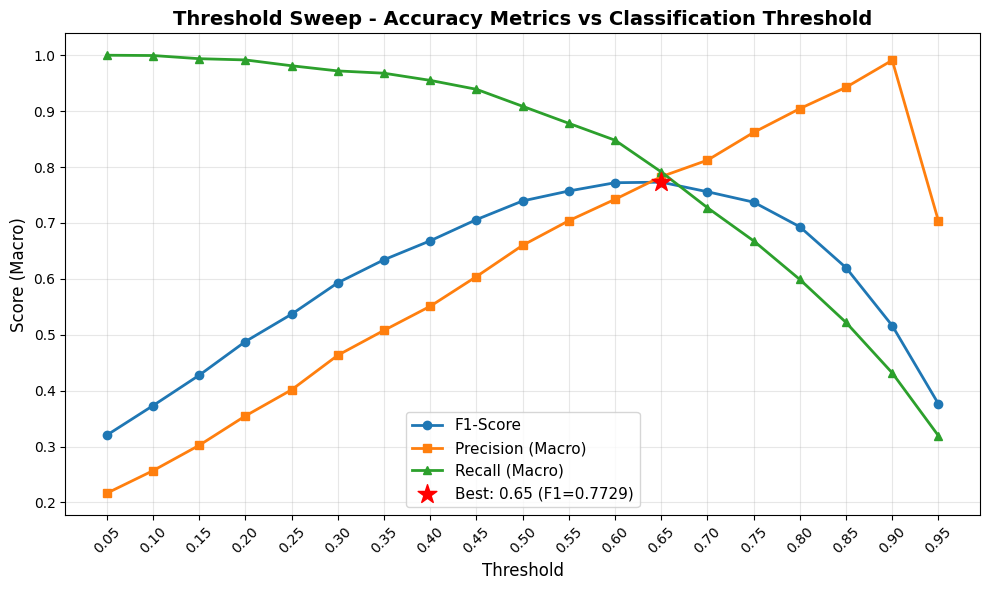

UsageError: Run (nx0fls64) is finished. The call to `log` will be ignored. Please make sure that you are using an active run.

In [ ]:
thresholds = np.arange(0.05, 1.0, 0.05)
f1_scores = []
precision_scores = []
recall_scores = []

for threshold in thresholds:
    precision, recall, _, p_macro, r_macro, f1_macro = evaluation.compute_accuracy_metrics_multilabel(
        model,
        val_loader,
        device,
        threshold=float(threshold)
    )

    f1_scores.append(f1_macro)
    precision_scores.append(p_macro)
    recall_scores.append(r_macro)
    
    print(f"Threshold: {threshold:.2f} | Precision: {p_macro:.4f} | Recall: {r_macro:.4f} | F1-Macro: {f1_macro:.4f}")

# Find best threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"\n✓ Best Threshold: {best_threshold:.2f} with F1-Score: {best_f1:.4f}")

# Create figure
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f1_scores, marker='o', linewidth=2, markersize=6, label='F1-Score')
plt.plot(thresholds, precision_scores, marker='s', linewidth=2, markersize=6, label='Precision (Macro)')
plt.plot(thresholds, recall_scores, marker='^', linewidth=2, markersize=6, label='Recall (Macro)')
plt.scatter([best_threshold], [best_f1], color='red', s=200, marker='*', 
           label=f'Best: {best_threshold:.2f} (F1={best_f1:.4f})', zorder=5)

plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score (Macro)', fontsize=12)
plt.title('Threshold Sweep - Accuracy Metrics vs Classification Threshold', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(thresholds, [f'{t:.2f}' for t in thresholds], rotation=45)
plt.legend(fontsize=11)
plt.tight_layout()

fig = plt.gcf()
plt.show()

## Test model on test dataset - Only on best model (unfrozen ViT with no augmentation / dropout)

In [33]:
# Evaluate model on test dataset using best threshold
test_dataset = MultiLabelDataset(test_df, class_names, processor, augment=None)
test_loader = DataLoader(test_dataset, batch_size=run.config.batch_size, shuffle=False)

# Compute metrics on test set with best threshold
test_precision, test_recall, test_f1, test_p_macro, test_r_macro, test_f1_macro = evaluation.compute_accuracy_metrics_multilabel(
    model,
    test_loader,
    device,
    threshold=best_threshold
)

print(f"Test Set Performance (Threshold: {best_threshold:.2f})")
print(f"Precision (Macro): {test_p_macro:.4f}")
print(f"Recall (Macro): {test_r_macro:.4f}")
print(f"F1-Score (Macro): {test_f1_macro:.4f}")
print("\nPer-class metrics:")
for i, class_name in enumerate(class_names):
    print(f"{class_name:15} - Precision: {test_precision[i]:.4f}, Recall: {test_recall[i]:.4f}, F1: {test_f1[i]:.4f}")

Test Set Performance (Threshold: 0.65)
Precision (Macro): 0.7616
Recall (Macro): 0.7620
F1-Score (Macro): 0.7460

Per-class metrics:
airplane        - Precision: 0.4043, Recall: 0.9500, F1: 0.5672
bare-soil       - Precision: 0.8333, Recall: 0.4861, F1: 0.6140
buildings       - Precision: 0.7453, Recall: 0.5725, F1: 0.6475
cars            - Precision: 0.7949, Recall: 0.7006, F1: 0.7447
chaparral       - Precision: 0.8261, Recall: 0.8261, F1: 0.8261
court           - Precision: 0.3784, Recall: 0.6667, F1: 0.4828
dock            - Precision: 0.9524, Recall: 1.0000, F1: 0.9756
field           - Precision: 1.0000, Recall: 0.8571, F1: 0.9231
grass           - Precision: 0.8784, Recall: 0.6667, F1: 0.7580
mobile-home     - Precision: 0.6250, Recall: 0.7500, F1: 0.6818
pavement        - Precision: 0.9221, Recall: 0.7690, F1: 0.8386
sand            - Precision: 0.6765, Recall: 0.7797, F1: 0.7244
sea             - Precision: 1.0000, Recall: 1.0000, F1: 1.0000
ship            - Precision: 1.0000

## Save model for later use

In [36]:
# Save a full training checkpoint (weights + key metadata) for reproducibility.
config.MODELS_DIR.mkdir(parents=True, exist_ok=True)

safe_run_name = re.sub(r"[^a-zA-Z0-9_-]+", "-", run.name.strip()).strip("-").lower()
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
checkpoint_name = f"{safe_run_name}_dino_multilabel_{timestamp}.pt"
checkpoint_path = config.MODELS_DIR / checkpoint_name

checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "model_class": model.__class__.__name__,
    "backbone_name": pretrained_model_name,
    "num_classes": num_classes,
    "class_names": list(class_names),
    "run_name": run.name,
    "run_id": run.id,
    "epoch": epoch + 1 if "epoch" in locals() else None,
    "dropout": float(run.config.dropout) if run.config.dropout else None,
    "learning_rate": float(run.config.learning_rate) if "learning_rate" in run.config else None,
    "backbone_learning_rate": float(run.config.backbone_learning_rate) if "backbone_learning_rate" in run.config else None,
    "batch_size": int(run.config.batch_size) if "batch_size" in run.config else None,
}

torch.save(checkpoint, checkpoint_path)
print(f"Saved checkpoint to: {checkpoint_path}")

Saved checkpoint to: C:\Users\tomer\OneDrive\Home\Projects\Deep-learning-land-use-classification\models\vit-unfrozen-02_dino_multilabel_20260422_110501.pt
